In [1]:
import data_loader
import plotting
import dispatch
from pathlib import Path
import pandas as pd

#CONSTANTS
CCGT_POWER=400 #MW
HEAT_RATE=1.95 #MW of gas to produce 1 MW of electricy
SWITCH_ON_COST=15000 #EUR
MIN_ON_TIME=4 #HOURS
MIN_OFF_TIME=4 #HOURS
EMISSION_FACTOR=0.37 # tons of CO2 per MWh of electricity produced
CO2_PRICE=70 #EUR/ton potentially to be replaced with price series


# CCGT valuation — data loading and analysis

Valuation of a combined-cycle gas turbine (CCGT) plant modelled as a
strip of spark-spread options, using 2023 Italian day-ahead electricity
prices (PUN) and Dutch TTF gas prices.

This notebook loads and inspects the price data; the valuation and
dispatch-optimization logic lives in the project modules.

## 1. Load price data

Hourly PUN and daily TTF prices are loaded and aligned by
`data_loader.load_pun_ttf_prices`, which merges the daily gas price onto
the hourly grid (forward-filled over weekends and holidays) and returns
a DataFrame indexed by hour of the year. Running with `diagnostic=True`
checks the load for missing values and the expected per-day hour counts.

In [2]:
pun_ttf_prices=data_loader.load_pun_ttf_prices(diagnostic=True)

display(pun_ttf_prices.head())
display(pun_ttf_prices.tail())

diagnostic OK: 8760 hours, 365 days (363 x 24h, one 23h, one 25h), no missing values


,time,pun_price,ttf_price
0,2023-01-01 00:00:00,195.90,76.315
1,2023-01-01 01:00:00,191.09,76.315
2,2023-01-01 02:00:00,187.95,76.315
3,2023-01-01 03:00:00,187.82,76.315
4,2023-01-01 04:00:00,187.74,76.315


,time,pun_price,ttf_price
8755,2023-12-31 19:00:00,136.07000,32.35
8756,2023-12-31 20:00:00,130.00000,32.35
8757,2023-12-31 21:00:00,117.23116,32.35
8758,2023-12-31 22:00:00,108.96000,32.35
8759,2023-12-31 23:00:00,106.12000,32.35


## 2. Computing and visualizing spark spread

In [3]:
pun_ttf_prices["spark_spread"]=dispatch.compute_spark_spread(
    pun_price=pun_ttf_prices["pun_price"], 
    ttf_price=pun_ttf_prices["ttf_price"], 
    heat_rate=HEAT_RATE, 
    emission_factor=EMISSION_FACTOR, 
    co2_price=CO2_PRICE,
)

pun_ttf_prices.head()

,time,pun_price,ttf_price,spark_spread
0,2023-01-01 00:00:00,195.90,76.315,21.18575
1,2023-01-01 01:00:00,191.09,76.315,16.37575
2,2023-01-01 02:00:00,187.95,76.315,13.23575
3,2023-01-01 03:00:00,187.82,76.315,13.10575
4,2023-01-01 04:00:00,187.74,76.315,13.02575


(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'Spark spread hourly — sample week'}, ylabel='€/MWh'>)

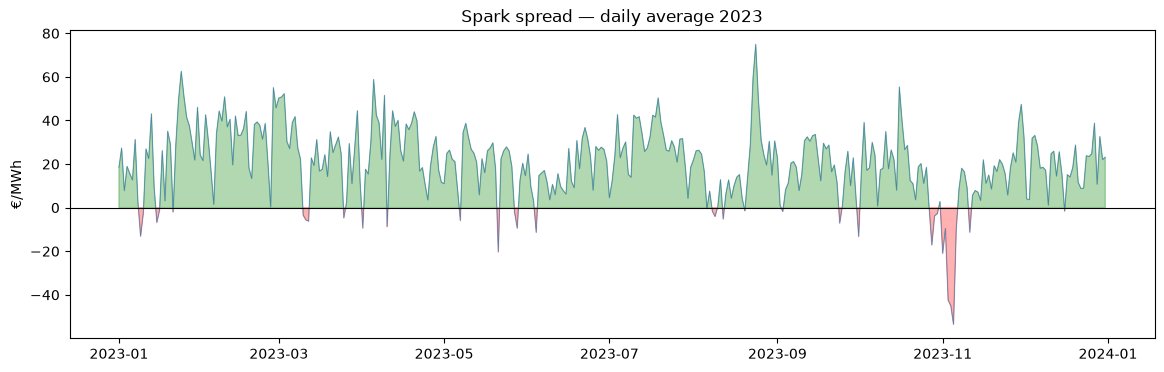

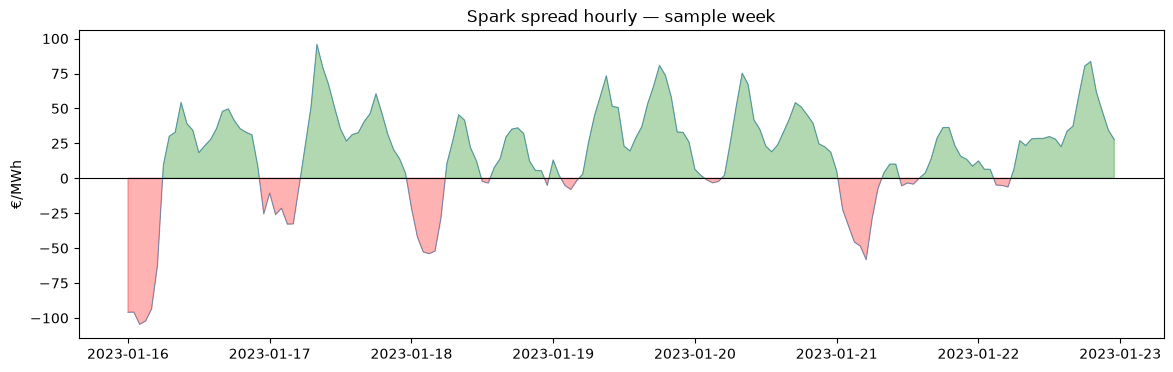

In [4]:
# media giornaliera
daily = (
    pun_ttf_prices.set_index("time")["spark_spread"]
    .resample("D")
    .mean()
)

plotting.plot_series_vs_threshold(
    daily.index, daily.values,
    title="Spark spread — daily average 2023", ylabel="€/MWh",
)

# settimana campione
week = pun_ttf_prices[(pun_ttf_prices["time"] >= "2023-01-16") &
              (pun_ttf_prices["time"] < "2023-01-23")]
plotting.plot_series_vs_threshold(
    week["time"], week["spark_spread"],
    title="Spark spread hourly — sample week", ylabel="€/MWh",
)

# 3.Optimization Strategies

### Naive Strategy: turbine always ON

In [5]:
total_revs_naive=pun_ttf_prices["spark_spread"].sum()*CCGT_POWER
formatted_revs_naive = f"{total_revs_naive:,.0f}".replace(",", " ")

print(
    f"""By keeping the turbine always ON,
in one year the total gross revenues is {formatted_revs_naive} EUR
"""
)

By keeping the turbine always ON,
in one year the total gross revenues is 71 917 741 EUR



### Ideal Strategy with no constraints: switching is free and always possible

In [6]:
total_revs_ideal=(
    pun_ttf_prices[pun_ttf_prices["spark_spread"]>0]["spark_spread"]
    .sum()*CCGT_POWER
)

formatted_revs_ideal = f"{total_revs_ideal:,.0f}".replace(",", " ")
diff_ideal_naive=total_revs_ideal-total_revs_naive

formatted_diff_ideal_naive = f"{diff_ideal_naive:,.0f}".replace(",", " ")

print(
    "If switching were free and always possible, in one year\n"
    f"the total gross revenues would be {formatted_revs_ideal} EUR,\n"
    f"which is {formatted_diff_ideal_naive} more than keeping\n"
    "the turbine always ON."
)

If switching were free and always possible, in one year
the total gross revenues would be 83 898 736 EUR,
which is 11 980 994 more than keeping
the turbine always ON.


### Optimal Strategy with physical constraints

In [7]:
constraints={
    "min_on_time":MIN_ON_TIME,
    "min_off_time":MIN_OFF_TIME,
    "switch_on_cost": SWITCH_ON_COST,
    "ccgt_power": CCGT_POWER
}

is_on_dispatch, optimal_real_revs = dispatch.compute_optimal_dispatch(
    hourly_prices=pun_ttf_prices, 
    constraints=constraints
)

pun_ttf_prices["optimal_dispatch"]=is_on_dispatch


n_startups=dispatch.count_startups(is_on_dispatch)

formatted_startup_costs= f"{n_startups*SWITCH_ON_COST:,.0f}".replace(",", " ")


formatted_revs_real = f"{optimal_real_revs:,.0f}".replace(",", " ")

run_at_loss=(
    pun_ttf_prices[(
        (pun_ttf_prices["spark_spread"]<0) & 
        (pun_ttf_prices["optimal_dispatch"]==True))]["spark_spread"]
    .sum()*CCGT_POWER
)
formatted_run_at_loss_costs= f"{abs(run_at_loss):,.0f}".replace(",", " ")


off_when_profitable=(
    pun_ttf_prices[
        ((pun_ttf_prices["spark_spread"]>0) & 
        (pun_ttf_prices["optimal_dispatch"]==False))]["spark_spread"]
    .sum()*CCGT_POWER
)
formatted_off_when_profitable_costs= f"{abs(off_when_profitable):,.0f}".replace(",", " ")

optimal_minus_naive=optimal_real_revs-total_revs_naive
formatted_optimal_minus_naive= f"{optimal_minus_naive:,.0f}".replace(",", " ")



### Saving outputs

In [8]:
Path("output").mkdir(parents=True, exist_ok=True)

dispatch_df = pd.DataFrame({
    "hour": range(len(is_on_dispatch)),
    "status": ["ON" if x else "OFF" for x in is_on_dispatch],
})

dispatch_df.to_csv("output/optimal_dispatch.csv", index=False)

summary_text=(
    f"The optimal dispatch, when considering constraints, has been saved\n in optimal_dispatch.csv.\n"
    f"Without constraints, that is if switching were free and always possible, the\n "
    f"total yearly profits would be {formatted_revs_ideal} EUR.\n"
    f"With the optimal dispatch, the yearly profits are {formatted_revs_real} EUR.\n"
    f"The difference is due to:\n" 
    f"- start-up costs, for a total {n_startups} start ups, that accounts "
    f"for a loss of {formatted_startup_costs} EUR,\n"
    f"- turbine ON at loss, when unprofitable, that accounts for "
    f"a loss of {formatted_run_at_loss_costs} EUR,\n"
    f"- turbine OFF when would be profitable that accounts for "
    f"a loss of {formatted_off_when_profitable_costs} EUR.\n"
    f"\n On the other hand, keeping the turbine always ON would generate only \n"
    f"{formatted_revs_naive} EUR, which is {formatted_optimal_minus_naive} EUR less "
    f"than the optimal strategy we computed."
)

print(summary_text)

with open("output/analysis_summary.txt", "w") as f:
    f.write(summary_text)

The optimal dispatch, when considering constraints, has been saved
 in optimal_dispatch.csv.
Without constraints, that is if switching were free and always possible, the
 total yearly profits would be 83 898 736 EUR.
With the optimal dispatch, the yearly profits are 80 991 005 EUR.
The difference is due to:
- start-up costs, for a total 134 start ups, that accounts for a loss of 2 010 000 EUR,
- turbine ON at loss, when unprofitable, that accounts for a loss of 805 928 EUR,
- turbine OFF when would be profitable that accounts for a loss of 91 803 EUR.

 On the other hand, keeping the turbine always ON would generate only 
71 917 741 EUR, which is 9 073 263 EUR less than the optimal strategy we computed.


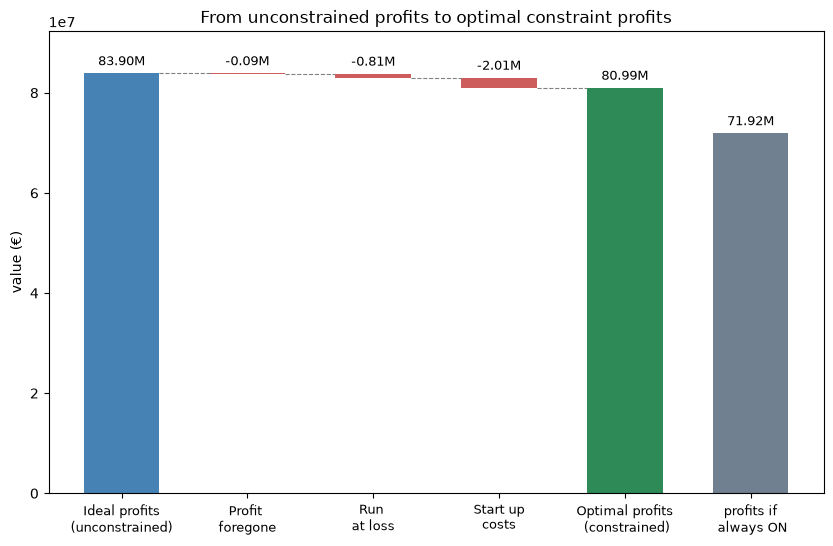

In [9]:
fig, ax = plotting.plot_value_waterfall(
    spark_spread=pun_ttf_prices["spark_spread"],
    is_on=is_on_dispatch,
    capacity=CCGT_POWER,
    n_startups=n_startups,
    switch_on_cost=SWITCH_ON_COST,
    value_optimal_dp=optimal_real_revs,
)
fig.savefig("output/value_waterfall.png", dpi=150, bbox_inches="tight")